Aqui se importa el dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/IA1Proyecto/bookreads_w_descriptions_ds.csv')

aqui se revisan las filas donde falta informacion

In [6]:
filas_nulas = df[df.isnull().any(axis=1)]
display(filas_nulas)
len(filas_nulas)

,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres,description
121,534,We Were Not Like Other People,Ephraim Sevela/Antonina W. Bouis,4.14,0060255080,9780060255084,eng,216,1,0,1/1/1989,HarperCollins Publishers,NaN,Separated from his family when the Germans inv...
174,955,The 5 Love Languages / The 5 Love Languages Jo...,Gary Chapman,4.70,0802415318,9780802415318,eng,0,22,4,1/1/2005,Moody Publishers,NaN,Chapman explains that the five languages of lo...
268,1506,CliffsNotes on Euripides' Medea and Electra,Robert J. Milch,4.20,0822004240,9780822004240,eng,69,5,0,9/13/1965,Cliffs Notes,NaN,The original CliffsNotes study guides offer ex...
836,4964,Love You Until--,Lisa McCourt/Cyd Moore,4.50,0809166585,9780809166589,eng,32,4,0,12/3/2005,Paulist Press,NaN,Mama and Mike take turns saying that they will...
967,5653,The Elephant War,Gillian Avery,3.67,1903252040,9781903252048,eng,256,19,3,10/1/2000,Jane Nissen Books,NaN,When P. T. Barnum decides to take Jumbo to Ame...
1224,7524,Presidential Assassins (History Makers),Patricia D. Netzley,3.60,1560066237,9781560066231,eng,112,5,1,9/1/1999,Lucent Books,NaN,Traces the lives and motives of American assas...
1446,8767,Touch & Feel: Animals Boxed Set,Jennifer Quasha/Deni Brown/Dawn Sirett,4.04,0789488779,9780789488770,eng,36,24,3,2/15/2003,DK Publishing,NaN,The book revolves on the struggles of young Cr...
1968,12256,The Iliad Books 8-9 (Classical Texts Series),Homer/Charles H. Wilson,4.50,0856686271,9780856686276,grc,224,4,1,12/1/1996,Aris and Phillips,NaN,This long-awaited new edition of Lattimore's I...
2347,14375,A Reading Guide to Island of the Blue Dolphins,Patricia McHugh,3.89,0439463696,9780439463690,eng,64,4,0,7/1/2003,Scholastic Reference,NaN,"Discusses the writing, characters, plot, and t..."
3115,19383,Cliffs Notes on Voltaire's Candide,James K. Lowers/CliffsNotes/Voltaire,3.40,0822002833,9780822002833,eng,80,9,3,3/29/1965,Cliffs Notes,NaN,The original CliffsNotes study guides offer ex...


23

aqui se revisa el tamaño actual del dataframe que se va a utilizar

In [7]:
len(df)

5997

aqui se miran cuantos generos unicos existen, antes de la simplificacion y la reduccion de los mismos.

In [ ]:
len(genres.unique())

735

El siguiente bloque hace lo siguiente: 1. Agrupa los géneros menos comunes (aquellos que no representan al 95% de los libros) en una sola categoría llamada 'Other' (Otros). Esto reduce la complejidad del modelo. 2. Luego, muestra una gráfica de barras con los 15 géneros más frecuentes para ver la nueva distribución de géneros.

Number of genres covering 95% of books: 248


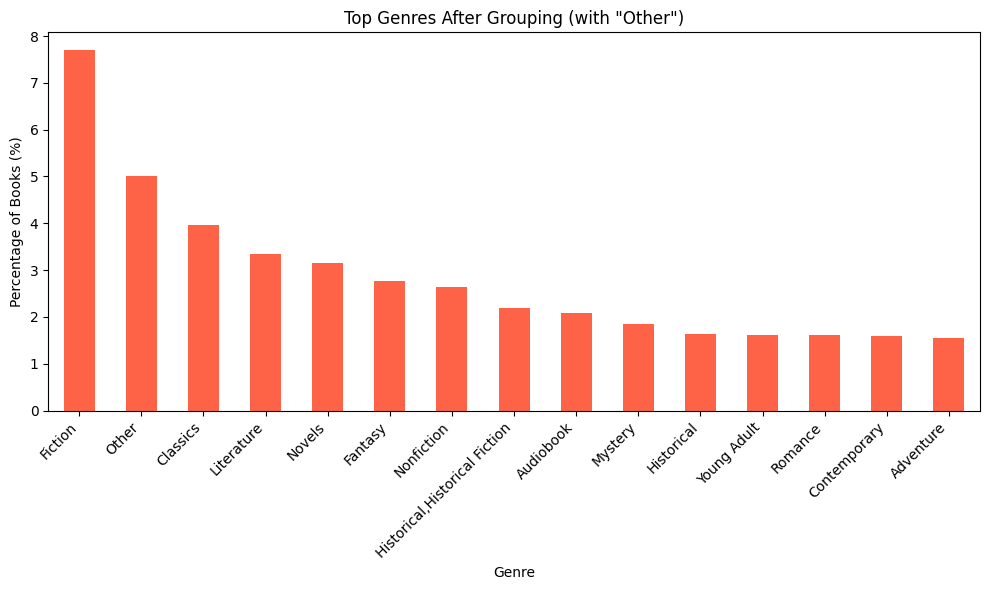

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: make a copy
newdf = df.copy()

# Step 2: split and flatten genres from the copy
genres = newdf['genres'].dropna().str.split(';').explode().str.strip()

# Step 3: get absolute counts and cumulative percentage
genre_counts = genres.value_counts()
cumulative = genre_counts.cumsum() / genre_counts.sum()

# Step 4: define the threshold (e.g. 90%)
threshold = 0.95
main_genres = cumulative[cumulative <= threshold].index

print(f"Number of genres covering {threshold*100:.0f}% of books:", len(main_genres))

# Step 5: create a cleaned version of the genres column
newdf['genres_cleaned'] = newdf['genres'].dropna().apply(
    lambda x: '; '.join(
        ['Other' if g.strip() not in main_genres else g.strip() for g in x.split(';')]
    )
)

# Step 6: plot the new distribution
genres_cleaned = newdf['genres_cleaned'].str.split(';').explode().str.strip()
conteo = genres_cleaned.value_counts(normalize=True) * 100

plt.figure(figsize=(10,6))
conteo.head(15).plot(kind='bar', color='tomato')
plt.title('Top Genres After Grouping (with "Other")')
plt.ylabel('Percentage of Books (%)')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


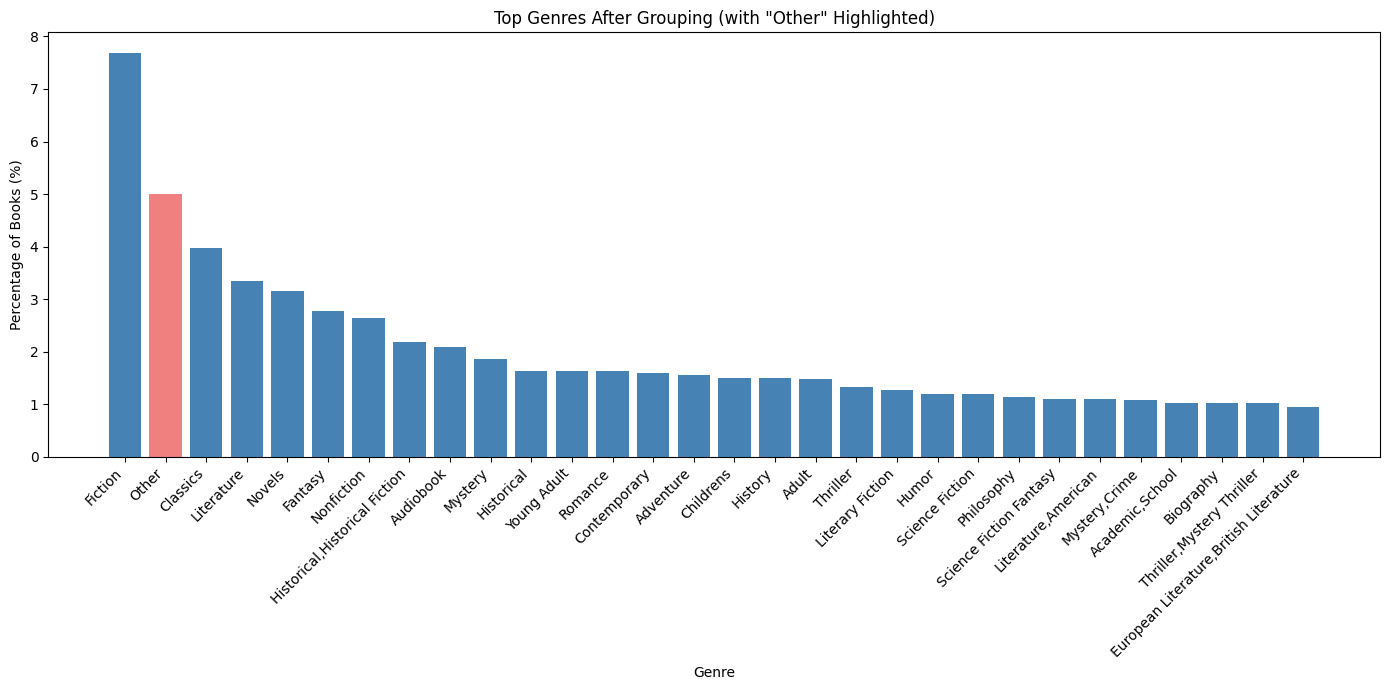

In [9]:
import matplotlib.pyplot as plt

# Reuse your cleaned genre distribution
genres_cleaned = newdf['genres_cleaned'].str.split(';').explode().str.strip()
distribution = genres_cleaned.value_counts(normalize=True) * 100

# Number of top genres to show
top_n = 30
top_genres = distribution.head(top_n)

# Pick a special color for "Other"
colors = ['lightcoral' if genre == 'Other' else 'steelblue' for genre in top_genres.index]

# Plot
plt.figure(figsize=(14,7))
bars = plt.bar(top_genres.index, top_genres.values, color=colors)
plt.title('Top Genres After Grouping (with "Other" Highlighted)')
plt.ylabel('Percentage of Books (%)')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Se continúa el análisis mostrando el promedio de libros por género y una lista de los principales géneros con su conteo de libros después de la limpieza y agrupación.

Average number of books per genre: 222.52

Top genres by book count:
genres_cleaned
Fiction                          4263
Other                            2776
Classics                         2200
Literature                       1849
Novels                           1749
Fantasy                          1534
Nonfiction                       1459
Historical,Historical Fiction    1209
Audiobook                        1157
Mystery                          1028
Name: count, dtype: int64


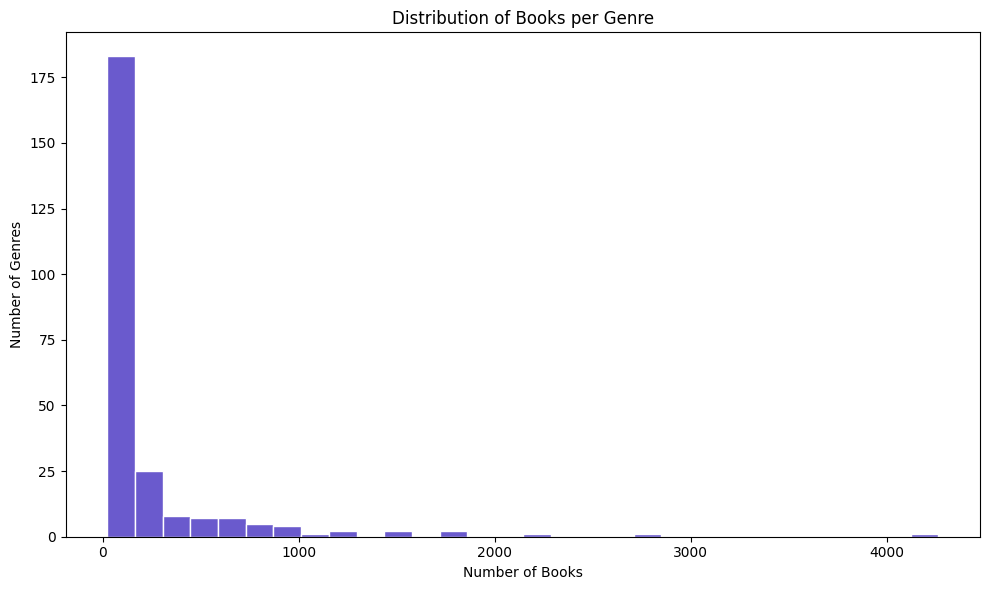

In [10]:
# Split genres into individual rows again
genres_cleaned = newdf['genres_cleaned'].str.split(';').explode().str.strip()

# Count how many books per genre
books_per_genre = genres_cleaned.value_counts()

# Calculate the average number of books per genre
average_books = books_per_genre.mean()

print(f"Average number of books per genre: {average_books:.2f}")

# Optional: see a quick summary
print("\nTop genres by book count:")
print(books_per_genre.head(10))

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(books_per_genre, bins=30, color='slateblue', edgecolor='white')
plt.title('Distribution of Books per Genre')
plt.xlabel('Number of Books')
plt.ylabel('Number of Genres')
plt.tight_layout()
plt.show()


In [11]:
import numpy as np

genres_cleaned = newdf['genres_cleaned'].str.split(';').explode().str.strip()
books_per_genre = genres_cleaned.value_counts()

mean_books = books_per_genre.mean()
median_books = books_per_genre.median()

print(f"Mean number of books per genre: {mean_books:.2f}")
print(f"Median number of books per genre: {median_books:.2f}")


Mean number of books per genre: 222.52
Median number of books per genre: 75.00


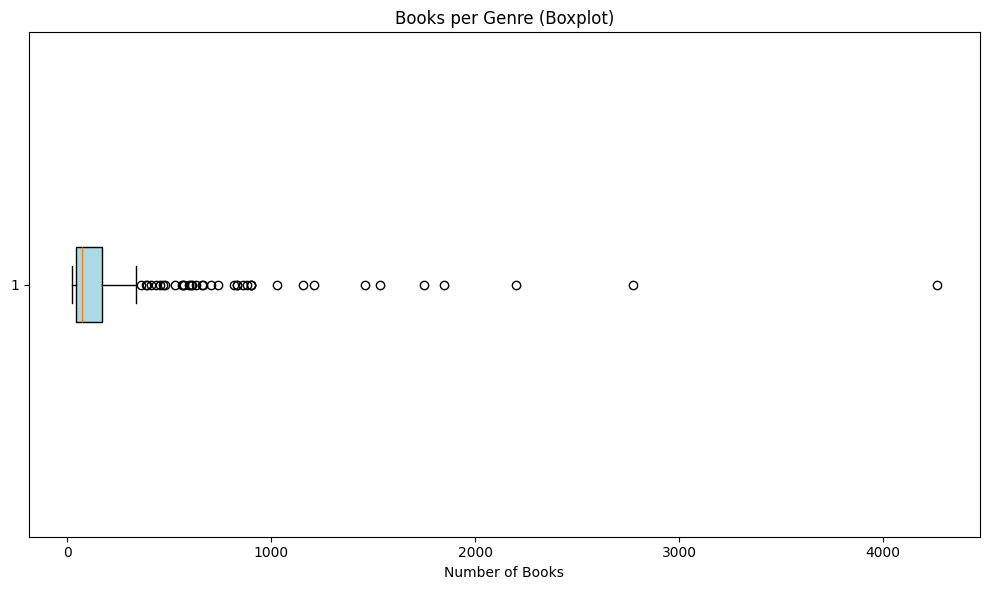

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.boxplot(books_per_genre, vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Books per Genre (Boxplot)')
plt.xlabel('Number of Books')
plt.tight_layout()
plt.show()


In [ ]:
# Random sample of 5 books
sample = newdf.sample(10, random_state=42)
display(sample)


,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres,description,genres_cleaned
84,354,To Sail Beyond the Sunset,Robert A. Heinlein,3.87,0441748600,9780441748600,en-US,434,10293,193,6/1/1988,Ace Books,Science Fiction;Fiction;Science Fiction Fantas...,"SciFi - Subtitled ""The Life and Loves of Maure...",Science Fiction; Fiction; Science Fiction Fant...
5875,44597,Wide Sargasso Sea,Jean Rhys,3.58,0140274219,9780140274219,eng,160,21384,1386,9/3/1998,Penguin Books,"Fiction;Classics;Historical,Historical Fiction...",Jean Rhys's reputation was made upon publicati...,"Fiction; Classics; Historical,Historical Ficti..."
787,4714,The Damned and the Beautiful: American Youth i...,Paula S. Fass,3.76,0195024923,9780195024920,spa,520,83,14,2/19/1978,Oxford University Press USA,"History;Nonfiction;Literature,American;Academi...",Explores the changes that occurred as young pe...,"History; Nonfiction; Literature,American; Acad..."
4375,30413,Betrogen,Sandra Brown,3.92,3764501359,9783764501358,ger,512,5,0,2/1/2003,Blanvalet Verlag GmbH,"Romance;Mystery;Romance,Romantic Suspense;Fict...",From #1 New York Times bestselling author Sand...,"Romance; Mystery; Romance,Romantic Suspense; F..."
79,332,The Wedding Clause,Debbie Raleigh,3.60,0821778250,9780821778258,eng,256,95,13,6/7/2005,Zebra,"Romance;Romance,Historical Romance;Historical,...",A GAME OF CHANCE\r\nMolly Conwell's life has b...,"Romance; Romance,Historical Romance; Historica..."
3336,21845,Assumed Identity,David Morrell,3.78,0446600709,9780446600705,eng,512,1118,46,9/1/1994,Vision,"Thriller;Fiction;Mystery;Spy Thriller,Espionag...",Filled with nonstop suspense and psychological...,"Thriller; Fiction; Mystery; Spy Thriller,Espio..."
538,3067,The Complete Stories,Bernard Malamud/Robert Giroux,4.22,0374525757,9780374525750,en-US,656,712,51,10/12/1998,Farrar Straus and Giroux,"Short Stories;Fiction;Literature;Literature,Je...",This volume brings together fifty-four stories...,Short Stories; Fiction; Literature; Literature...
2114,13028,Alice In Wonderland,Lewis Carroll/John Tenniel,4.02,0439291496,9780439291491,eng,160,143,18,9/1/2001,Scholastic Paperbacks,Classics;Fantasy;Fiction;Childrens;Audiobook;A...,"One normal summer day, Alice is sitting on the...",Classics; Fantasy; Fiction; Childrens; Audiobo...
3937,26930,Success Stories,Russell Banks,3.72,0060927194,9780060927196,en-US,192,155,11,4/26/1996,Harper Perennial,Short Stories;Fiction,The play concerns a trusted general who secret...,Short Stories; Fiction
5753,43441,A Tramp Abroad,Mark Twain/Dave Eggers,3.86,0812970039,9780812970036,eng,400,26,9,10/14/2003,Modern Library,Travel;Classics;Humor;Fiction;Literature;Liter...,"""In A Tramp Abroad, Mark Twain's unofficial se...",Travel; Classics; Humor; Fiction; Literature; ...


In [13]:
# Crear una copia para no tocar el original
limited_df = newdf.copy()

# Función para limitar géneros a máximo 3 únicos
def limitar_generos(genres_str, max_genres=3):
    if pd.isna(genres_str):
        return genres_str
    # dividir, limpiar espacios y eliminar duplicados
    genres = list(dict.fromkeys([g.strip() for g in genres_str.split(';') if g.strip()]))
    # limitar a los primeros 3
    return '; '.join(genres[:max_genres])

# Aplicar la función
limited_df['genres_limited'] = limited_df['genres_cleaned'].apply(limitar_generos)

# Revisar un ejemplo
print(limited_df[['Title', 'genres_cleaned', 'genres_limited']].head(10))


                                               Title  \
0  Harry Potter and the Half-Blood Prince (Harry ...   
1  Harry Potter and the Order of the Phoenix (Har...   
2  Harry Potter and the Chamber of Secrets (Harry...   
3  Harry Potter and the Prisoner of Azkaban (Harr...   
4       Harry Potter Collection (Harry Potter  #1-6)   
5  The Ultimate Hitchhiker's Guide: Five Complete...   
6  The Ultimate Hitchhiker's Guide to the Galaxy ...   
7  The Hitchhiker's Guide to the Galaxy (Hitchhik...   
8  The Hitchhiker's Guide to the Galaxy (Hitchhik...   
9  The Ultimate Hitchhiker's Guide (Hitchhiker's ...   

                                      genres_cleaned  \
0  Fantasy; Young Adult; Fiction; Fantasy,Magic; ...   
1  Fantasy; Young Adult; Fiction; Fantasy,Magic; ...   
2  Fantasy; Fiction; Young Adult; Fantasy,Magic; ...   
3  Fantasy; Fiction; Young Adult; Fantasy,Magic; ...   
4  Fantasy; Fiction; Young Adult; Fantasy,Magic; ...   
5  Science Fiction; Fiction; Humor; Fantasy; Cl

In [14]:
# Split, flatten and count unique genres in the new column
genres_limited = limited_df['genres_limited'].dropna().str.split(';').explode().str.strip()
unique_genres = genres_limited.unique()

print(f"Number of unique genres remaining: {len(unique_genres)}")


Number of unique genres remaining: 216


In [15]:
# Optional – see them sorted by frequency
genre_counts = genres_limited.value_counts()
print(genre_counts.head(20))  # top 20


genres_limited
Fiction                          3607
Classics                         1429
Nonfiction                       1326
Fantasy                           814
Mystery                           604
Historical,Historical Fiction     596
History                           429
Young Adult                       407
Childrens                         406
Romance                           399
Science Fiction                   364
Other                             352
Thriller                          327
Short Stories                     274
Biography                         273
Philosophy                        273
Horror                            254
Humor                             233
Literature                        206
Contemporary                      204
Name: count, dtype: int64


In [16]:
min_books = 200  # or higher
import re
common_genres = genres_limited.value_counts()[lambda x: x >= min_books].index
filtered_df = limited_df[
    limited_df['genres_limited']
    .fillna('')
    .str.contains('|'.join(map(re.escape, common_genres)))
]


In [17]:
import pandas as pd

# Flatten genres again, count, get top 30
genres_flat = limited_df['genres_limited'].dropna().str.split(';').explode().str.strip()
top30 = genres_flat.value_counts().head(30).index.tolist()

# Copy df to avoid corruption of your sacred original
final_df = limited_df.copy()

# Replace genres not in top 30 with 'Other'
def limit_to_top30(genre_str):
    if pd.isna(genre_str):
        return genre_str
    genres = [g.strip() for g in genre_str.split(';')]
    genres = [g if g in top30 else 'Other' for g in genres]
    genres = list(dict.fromkeys(genres))  # remove duplicates
    return ';'.join(genres[:3])  # still keep max 3

final_df['genres_limited'] = final_df['genres_limited'].apply(limit_to_top30)

# sanity check
genres_new = final_df['genres_limited'].dropna().str.split(';').explode().str.strip()
print("Unique genres after trim:", len(genres_new.unique()))
print(genres_new.value_counts().head(40))


Unique genres after trim: 30
genres_limited
Fiction                          3607
Other                            2998
Classics                         1429
Nonfiction                       1326
Fantasy                           814
Mystery                           604
Historical,Historical Fiction     596
History                           429
Young Adult                       407
Childrens                         406
Romance                           399
Science Fiction                   364
Thriller                          327
Short Stories                     274
Biography                         273
Philosophy                        273
Horror                            254
Humor                             233
Literature                        206
Contemporary                      204
Poetry                            194
Childrens,Picture Books           168
Mystery,Crime                     157
Autobiography,Memoir              156
Science                           138
Plays 

In [ ]:
display(final_df.sample(10))

,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres,description,genres_cleaned,genres_limited
1191,7220,The Secret Life of Bees,Sue Monk Kidd,4.05,0143036408,9780143036401,eng,302,1284,169,10/4/2005,Penguin Books,"Fiction;Historical,Historical Fiction;Young Ad...",Sue Monk Kidd's ravishing debut novel has stol...,"Fiction; Historical,Historical Fiction; Young ...","Fiction;Historical,Historical Fiction;Young Adult"
4208,29312,Riddley Walker,Russell Hoban,4.03,074755904X,9780747559047,eng,236,305,44,2/1/2010,Bloomsbury,"Fiction;Science Fiction;Apocalyptic,Post Apoca...",Engrossing post apocalyptic book that told ent...,"Fiction; Science Fiction; Apocalyptic,Post Apo...",Fiction;Science Fiction;Other
1613,10029,The Philosophy of Jean-Paul Sartre,Jean-Paul Sartre,3.89,1400076323,9781400076321,eng,512,190,8,5/27/2003,Vintage,Philosophy;Nonfiction,"A fascinating existentialist novel, written in...",Philosophy; Nonfiction,Philosophy;Nonfiction
310,1752,Antigone,Sophocles/Reginald Gibbons/Charles Segal,3.64,0195143108,9780195143102,eng,197,36,5,9/1/2007,Oxford University Press,"Classics;Plays;Drama;Fiction;Academic,School;F...",Publisher's description: Echoing through weste...,"Classics; Plays; Drama; Fiction; Academic,Scho...",Classics;Plays;Other
306,1730,Metamorphoses: Volume I Books I-VIII,Ovid/Frank Justus Miller,4.42,0674990463,9780674990463,eng,496,813,14,1/1/1977,Harvard University Press,"Classics;Poetry;Fantasy,Mythology;Fiction;Lite...",The Metamorphoses is a narrative poem penned b...,"Classics; Poetry; Fantasy,Mythology; Fiction; ...",Classics;Poetry;Other
4835,34157,Political Philosophy: A Beginner's Guide for S...,Adam Swift,3.93,0745628478,9780745628479,eng,194,6,0,10/15/2001,Polity Press,Philosophy;Nonfiction;Politics;Academic;Politi...,Bringing political philosophy out of the ivory...,Philosophy; Nonfiction; Politics; Academic; Po...,Philosophy;Nonfiction;Other
5006,35807,The Rescue (Guardians of Ga'Hoole #3),Kathryn Lasky,4.07,0439405599,9780439405591,eng,198,10154,278,1/1/2004,Scholastic Inc.,"Fantasy;Animals;Fiction;Childrens,Middle Grade...","197 pages : illustrations, maps ; 20 cm.850L L...","Fantasy; Animals; Fiction; Childrens,Middle Gr...",Fantasy;Other;Fiction
2733,16888,John James Audubon,Richard Rhodes,4.13,037571393X,9780375713934,eng,528,460,65,4/11/2006,Vintage,"Biography;Nonfiction;History;Animals,Birds;Env...","""From the historian Richard Rhodes, the first ...",Biography; Nonfiction; History; Other; Environ...,Biography;Nonfiction;History
3317,21745,Without Fail (Jack Reacher #6),Lee Child/Dick Hill,4.15,1590860624,9781590860625,eng,14,64395,1617,5/17/2002,Brilliance Audio,"Thriller;Fiction;Mystery;Mystery,Crime;Action;...","Skilled, cautious, and anonymous, Jack Reacher...","Thriller; Fiction; Mystery; Mystery,Crime; Act...",Thriller;Fiction;Mystery
4720,33151,The Tempest,William Shakespeare/Peter Hulme/William H. She...,3.81,0393978192,9780393978193,eng,355,582,30,12/23/2003,W. W. Norton & Company,"Classics;Plays;Drama;Fiction;Fantasy;Academic,...","The Tempest is a play by William Shakespeare, ...",Classics; Plays; Drama; Fiction; Fantasy; Acad...,Classics;Plays;Other


Se preparan las descripciones de los libros (texto) para el modelo. Usa la técnica TF-IDF para convertir las palabras de las descripciones en números (vectores). Esta técnica da más importancia a las palabras que son únicas e importantes para un libro, pero no tan comunes en toda la biblioteca.

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression # Import LogisticRegression


# Assuming your cleaned dataframe is called final_df
# and columns are: 'description' and 'genres_limited'

# Prepare text and target
final_df = final_df.dropna(subset=['description', 'genres_limited'])
X = final_df['description']

# Genres as lists
y = final_df['genres_limited'].str.split(';').apply(lambda x: [g.strip() for g in x])

# Transform text into TF-IDF features
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20000,
    ngram_range=(1, 2)
)
X_tfidf = vectorizer.fit_transform(X)

# Binarize the genre labels (multi-label setup)
mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_binarized, test_size=0.2, random_state=42
)

# Train model (One-vs-Rest for multi-label)
model = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=2, solver='liblinear'))
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

Accuracy: 0.11464435146443515
                               precision    recall  f1-score   support

         Autobiography,Memoir       0.00      0.00      0.00        33
                    Biography       1.00      0.02      0.03        63
                    Childrens       1.00      0.08      0.15        87
      Childrens,Picture Books       0.00      0.00      0.00        29
                     Classics       0.91      0.38      0.54       294
                 Contemporary       0.00      0.00      0.00        36
                      Fantasy       0.94      0.30      0.45       160
                      Fiction       0.77      0.92      0.84       726
                   Historical       0.00      0.00      0.00        27
Historical,Historical Fiction       0.92      0.09      0.16       136
                      History       0.90      0.12      0.21        75
                       Horror       0.88      0.11      0.20        62
                        Humor       1.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Aqui se realiza el entrenamiento de los modelos con sus respectivas metricas.

In [ ]:
from sklearn.naive_bayes import MultinomialNB

print("--- Entrenando Modelo: Multinomial Naive Bayes ---")

# 1. Definir el modelo base y el clasificador One-vs-Rest
# Usamos MultinomialNB, que es estándar para clasificación de texto con TF-IDF
base_model_nb = MultinomialNB()
ovr_model_nb = OneVsRestClassifier(base_model_nb)

# 2. Definir los hiperparámetros a probar
# 'estimator__alpha' es la forma de acceder al parámetro 'alpha' del modelo base (NB)
# dentro del OneVsRestClassifier
parameters_nb = {
    'estimator__alpha': [0.1, 0.5, 1.0]  # Alpha es el parámetro de suavizado
}

# 3. Configurar GridSearchCV
# cv=5 significa que usará Validación Cruzada de 5 Folds (K-Fold)
grid_search_nb = GridSearchCV(ovr_model_nb, parameters_nb, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)

# 4. Entrenar
grid_search_nb.fit(X_train, y_train)

# 5. Mostrar mejores hiperparámetros
print("\n--- Resultados de Naive Bayes ---")
print(f"Mejores Hiperparámetros encontrados: {grid_search_nb.best_params_}")

# 6. Evaluar el mejor modelo en los datos de prueba
y_pred_nb = grid_search_nb.best_estimator_.predict(X_test)
print("\nReporte de Clasificación (Prueba):")
print(classification_report(y_test, y_pred_nb, target_names=mlb.classes_, zero_division=0))
print(f"Accuracy (Exact Match): {accuracy_score(y_test, y_pred_nb)}")

--- Entrenando Modelo: Multinomial Naive Bayes ---
Fitting 5 folds for each of 3 candidates, totalling 15 fits

--- Resultados de Naive Bayes ---
Mejores Hiperparámetros encontrados: {'estimator__alpha': 0.1}

Reporte de Clasificación (Prueba):
                               precision    recall  f1-score   support

         Autobiography,Memoir       0.15      0.06      0.09        33
                    Biography       0.17      0.06      0.09        63
                    Childrens       0.57      0.23      0.33        87
      Childrens,Picture Books       0.12      0.07      0.09        29
                     Classics       0.90      0.49      0.64       294
                 Contemporary       0.33      0.19      0.25        36
                      Fantasy       0.81      0.49      0.61       160
                      Fiction       0.78      0.86      0.82       726
                   Historical       0.08      0.04      0.05        27
Historical,Historical Fiction       0.62    


### **Métricas de Evaluación por genero**

Para analizar el desempeño del modelo en la clasificación de textos literarios, se emplearon las siguientes métricas:

* **Precisión (Precision):**
  Indica, de todos los libros que el modelo predijo como pertenecientes a un determinado género, qué porcentaje realmente corresponde a ese género.
  *Ejemplo:* el 81% de las veces que el modelo clasificó un libro como **“Ficción”**, efectivamente lo era.

* **Sensibilidad (Recall):**
  Mide qué porcentaje de los libros que realmente pertenecen a un género fueron correctamente identificados por el modelo.
  *Ejemplo:* el modelo logró reconocer correctamente el 87% de los libros que realmente eran **“Ficción”**.

* **F1-Score:**
  Representa el promedio balanceado entre la precisión y la sensibilidad. Es una métrica integral para evaluar el rendimiento general del modelo en cada género.
  *Ejemplo:* para **“Ficción”**, el F1-Score fue **0.84**, lo que refleja un desempeño excelente.

* **Soporte (Support):**
  Indica la cantidad real de ejemplos de cada género en el conjunto de prueba.
  *Ejemplo:* existen **786 libros de “Ficción”** en los datos de prueba, lo que corresponde al 20% del total.

---



### **Métricas Globales del Modelo**

Además de evaluar el rendimiento por género, se analizaron métricas globales que permiten entender el desempeño general del modelo en la tarea de **clasificación multietiqueta**:

* **Promedio Ponderado (Weighted Avg):**
  Es la métrica más representativa del rendimiento global. Calcula el promedio del *F1-score* y otras métricas, asignando mayor peso a los géneros con más ejemplos (mayor *support*), como **“Ficción”** y **“Other”**.
  *Resultado obtenido:* **F1-score = 0.62**, lo que representa un buen punto de partida para este tipo de clasificación.

* **Promedio Micro (Micro Avg):**
  Se obtiene considerando todos los aciertos globales del modelo, sin distinguir entre clases. Tiende a estar influido por los géneros más grandes, especialmente **“Other”** en este caso.
  *Resultado obtenido:* **F1-score = 0.65**.

* **Promedio Macro (Macro Avg):**
  Calcula el promedio simple de las métricas de todos los géneros, sin tener en cuenta la cantidad de ejemplos de cada uno.
  *Resultado obtenido:* **F1-score = 0.30**, lo que indica que el modelo presenta dificultades para clasificar géneros con pocos datos (aquellos que obtuvieron valores cercanos a 0.00 en el reporte).

* **Exactitud (Accuracy o Exact Match):**
  Mide el porcentaje de libros del conjunto de prueba para los cuales el modelo predijo correctamente **todas** las etiquetas asignadas (por ejemplo, si un libro era “Ficción” y “Misterio”, el modelo debió acertar exactamente ambas).
  *Resultado obtenido:* **0.222 (22.2%)**, un valor esperado en tareas de clasificación multietiqueta, donde la coincidencia exacta suele ser difícil de lograr.

---


Modelo 2: Árbol de Decisión (Decision Tree)
Explicación: Este modelo crea un conjunto de "reglas" (como un diagrama de flujo) para decidir el género. Es fácil de entender pero tiende a sobreajustarse si no limitamos su profundidad (max_depth).

In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("\n--- Entrenando Modelo: Árbol de Decisión ---")

# 1. Definir el modelo base y el clasificador One-vs-Rest
base_model_dt = DecisionTreeClassifier(random_state=42)
ovr_model_dt = OneVsRestClassifier(base_model_dt)

# 2. Definir los hiperparámetros a probar
# 'estimator__max_depth' controla qué tan profundo puede crecer el árbol
parameters_dt = {
    'estimator__max_depth': [10, 50, 100, None] # None = sin límite
}

# 3. Configurar GridSearchCV (cv=5 para K-Fold)
grid_search_dt = GridSearchCV(ovr_model_dt, parameters_dt, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)

# 4. Entrenar
grid_search_dt.fit(X_train, y_train)

# 5. Mostrar mejores hiperparámetros
print("\n--- Resultados del Árbol de Decisión ---")
print(f"Mejores Hiperparámetros encontrados: {grid_search_dt.best_params_}")

# 6. Evaluar el mejor modelo en los datos de prueba
y_pred_dt = grid_search_dt.best_estimator_.predict(X_test)
print("\nReporte de Clasificación (Prueba):")
print(classification_report(y_test, y_pred_dt, target_names=mlb.classes_, zero_division=0))
print(f"Accuracy (Exact Match): {accuracy_score(y_test, y_pred_dt)}")


--- Entrenando Modelo: Árbol de Decisión ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits

--- Resultados del Árbol de Decisión ---
Mejores Hiperparámetros encontrados: {'estimator__max_depth': None}

Reporte de Clasificación (Prueba):
                               precision    recall  f1-score   support

         Autobiography,Memoir       0.18      0.18      0.18        33
                    Biography       0.44      0.32      0.37        63
                    Childrens       0.46      0.40      0.43        87
      Childrens,Picture Books       0.17      0.14      0.15        29
                     Classics       0.58      0.51      0.54       294
                 Contemporary       0.23      0.28      0.25        36
                      Fantasy       0.57      0.55      0.56       160
                      Fiction       0.75      0.77      0.76       726
                   Historical       0.22      0.19      0.20        27
Historical,Historical Fiction       0

Modelo 3: Bosque Aleatorio (Random Forest)
Explicación: Este es uno de los modelos más robustos. En lugar de un solo árbol, construye un "bosque" de muchos árboles (controlado por n_estimators) y promedia sus decisiones.

Nota: Este modelo es muy lento de entrenar. Usaremos RandomizedSearchCV (que prueba combinaciones al azar) en lugar de GridSearchCV (que prueba todo) para obtener un buen resultado más rápido.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier
import gc

print("\n--- Entrenando Modelo: Random Forest (optimizado) ---")

# Liberar memoria justo antes por si hay variables grandes
gc.collect()

# 1. Definir el modelo base - NOTA: n_jobs=1 para evitar oversubscription
base_model_rf = RandomForestClassifier(random_state=42, n_jobs=1)
ovr_model_rf = OneVsRestClassifier(base_model_rf, n_jobs=1)

# 2. Hiperparámetros (mantén simples y cortos para búsqueda rápida)
parameters_rf = {
    'estimator__n_estimators': [100, 200],       # Mantener moderado
    'estimator__max_depth': [50, 100, None],
    'estimator__min_samples_leaf': [1, 5]
}

# 3. RandomizedSearchCV: paralelizamos en el outer-level con n_jobs=-1
random_search_rf = RandomizedSearchCV(
    ovr_model_rf,
    param_distributions=parameters_rf,
    n_iter=5,          # número de combinaciones aleatorias
    cv=3,              # reducir a 3 folds (más rápido). Usa 5 si el dataset es pequeño.
    scoring='f1_weighted',
    verbose=2,
    n_jobs=-1,         # paraleliza aquí (outer-level)
    random_state=42
)

# 4. Entrenar (mide tiempo con %%time si quieres)
random_search_rf.fit(X_train, y_train)

# 5. Resultados
print("\n--- Resultados de Random Forest ---")
print(f"Mejores Hiperparámetros encontrados: {random_search_rf.best_params_}")

# 6. Evaluar
y_pred_rf = random_search_rf.best_estimator_.predict(X_test)
print("\nReporte de Clasificación (Prueba):")
print(classification_report(y_test, y_pred_rf, target_names=mlb.classes_, zero_division=0))
print(f"Accuracy (Exact Match): {accuracy_score(y_test, y_pred_rf)}")



--- Entrenando Modelo: Random Forest (optimizado) ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits

--- Resultados de Random Forest ---
Mejores Hiperparámetros encontrados: {'estimator__n_estimators': 200, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': None}

Reporte de Clasificación (Prueba):
                               precision    recall  f1-score   support

         Autobiography,Memoir       1.00      0.06      0.11        33
                    Biography       0.40      0.03      0.06        63
                    Childrens       0.78      0.16      0.27        87
      Childrens,Picture Books       0.50      0.03      0.06        29
                     Classics       0.92      0.37      0.53       294
                 Contemporary       1.00      0.22      0.36        36
                      Fantasy       0.92      0.35      0.51       160
                      Fiction       0.76      0.90      0.82       726
                   Historical       0.

Modelo 4: Support Vector Machine (SVM)
Explicación: Los SVM son excelentes para la clasificación de texto. Tratan de encontrar el mejor "plano" que separe los datos. El parámetro C (costo) controla el equilibrio entre clasificar todo bien y permitir algunos errores (un C más alto intenta clasificar todo perfectamente, pero puede sobreajustar).

In [21]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV # Import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier # Import OneVsRestClassifier


print("\n--- Entrenando Modelo: Support Vector Machine (SVM) ---")


# 1. Usamos LinearSVC (más rápido para texto) y lo envolvemos en OneVsRest
base_model_svm = LinearSVC(random_state=42, dual=False, max_iter=2000)
ovr_model_svm = OneVsRestClassifier(base_model_svm)

# 2. Definir los hiperparámetros a probar
# 'estimator__C' es el parámetro de regularización
parameters_svm = {
    'estimator__C': [0.1, 1, 10]
}

# 3. Configurar GridSearchCV (cv=5 para K-Fold)
grid_search_svm = GridSearchCV(ovr_model_svm, parameters_svm, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)

# 4. Entrenar
grid_search_svm.fit(X_train, y_train)

# 5. Mostrar mejores hiperparámetros
print("\n--- Resultados de SVM ---")
print(f"Mejores Hiperparámetros encontrados: {grid_search_svm.best_params_}")

# 6. Evaluar el mejor modelo en los datos de prueba
y_pred_svm = grid_search_svm.best_estimator_.predict(X_test)
print("\nReporte de Clasificación (Prueba):")
print(classification_report(y_test, y_pred_svm, target_names=mlb.classes_, zero_division=0))
print(f"Accuracy (Exact Match): {accuracy_score(y_test, y_pred_svm)}")


--- Entrenando Modelo: Support Vector Machine (SVM) ---
Fitting 5 folds for each of 3 candidates, totalling 15 fits

--- Resultados de SVM ---
Mejores Hiperparámetros encontrados: {'estimator__C': 10}

Reporte de Clasificación (Prueba):
                               precision    recall  f1-score   support

         Autobiography,Memoir       1.00      0.09      0.17        33
                    Biography       0.70      0.25      0.37        63
                    Childrens       0.80      0.47      0.59        87
      Childrens,Picture Books       0.64      0.24      0.35        29
                     Classics       0.81      0.61      0.70       294
                 Contemporary       0.90      0.25      0.39        36
                      Fantasy       0.83      0.56      0.67       160
                      Fiction       0.78      0.85      0.81       726
                   Historical       0.60      0.11      0.19        27
Historical,Historical Fiction       0.84      0.38 

Modelo 5: Deep Learning (Redes Neuronales)
Explicación: Este es un enfoque diferente. No usa TF-IDF. En su lugar, usa "Embeddings" (vectores que aprenden el significado de las palabras) y redes neuronales para capturar patrones más complejos. Es mucho más lento de entrenar pero puede ser más potente.

Nota: Este código requiere tensorflow y keras. Es una estructura completamente diferente

In [23]:
# ---------------------------
# Entrenamiento DL (versión mejorada y completa)
# ---------------------------
import numpy as np
import os
import json
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, hamming_loss, classification_report, accuracy_score

# 0) Semilla para reproducibilidad (parcial)
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# ---------------------------
# A) Datos: texto y etiquetas multilabel
# ---------------------------
# Asumo que tienes `final_df['description']` y `final_df['genres_limited']` (separadas por ';')
X_text = final_df['description'].astype(str).values
y_strings = final_df['genres_limited'].astype(str).str.split(';').apply(lambda x: [g.strip() for g in x]).values

# Binarizar etiquetas
mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y_strings)  # shape = (n_samples, n_classes)
num_classes = y_binarized.shape[1]
print(f"Clases detectadas: {num_classes} -> {mlb.classes_}")

# ---------------------------
# B) Tokenización y padding
# ---------------------------
max_vocab_size = 20000   # ajustar si es necesario
max_seq_length = 250     # ajustar según la distribución de longitudes

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_text)
X_seq = tokenizer.texts_to_sequences(X_text)
X_pad = pad_sequences(X_seq, maxlen=max_seq_length, padding='post', truncating='post')

# ---------------------------
# C) Split: train / val / test
# ---------------------------
# Primero separamos test, luego de train hacemos train/val
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_pad, y_binarized, test_size=0.20, random_state=seed, stratify=None
)

# Ahora split train -> train/val (usamos 10% de train para val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.12, random_state=seed
)

print("Shapes -> X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

# ---------------------------
# D) Arquitectura del modelo (Embedding + Conv1D + GlobalMaxPooling)
# ---------------------------
embedding_dim = 100

model = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='sigmoid')  # multietiqueta
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ---------------------------
# E) Callbacks y parámetros de entrenamiento
# ---------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_dl.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

epochs = 30
batch_size = 64

# ---------------------------
# F) Entrenar (usa validation data explícita para poder ajustar thresholds luego)
# ---------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)

# ---------------------------
# G) Predicciones con probabilidades
# ---------------------------
y_val_proba = model.predict(X_val)    # usado para ajustar thresholds por clase
y_test_proba = model.predict(X_test)  # usado para evaluar final

# ---------------------------
# H) Ajustar umbrales por clase optimizando F1 en validation
# ---------------------------
best_thresholds = np.full(shape=(num_classes,), fill_value=0.5)  # default 0.5
threshold_grid = np.linspace(0.1, 0.9, 17)  # 0.1,0.15,...,0.9

for i in range(num_classes):
    best_f1 = -1.0
    best_t = 0.5
    y_true_i = y_val[:, i]
    # Si la clase no tiene ejemplos positivos en val, mantén 0.5
    if y_true_i.sum() == 0:
        best_thresholds[i] = 0.5
        continue
    for t in threshold_grid:
        preds_i = (y_val_proba[:, i] > t).astype(int)
        f1 = f1_score(y_true_i, preds_i, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds[i] = best_t

print("Umbrales por clase (primeras 20):", best_thresholds[:20])

# ---------------------------
# I) Aplicar umbrales en test y evaluar
# ---------------------------
y_test_pred = (y_test_proba > best_thresholds).astype(int)  # broadcasting: good shape (n_samples, n_classes)

# Métricas multilabel
f1_micro = f1_score(y_test, y_test_pred, average='micro', zero_division=0)
f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
hamming = hamming_loss(y_test, y_test_pred)
exact_match = accuracy_score(y_test, y_test_pred)  # exact match, usualmente baja en multilabel

print("\n--- Evaluación final en Test ---")
print(f"F1 micro: {f1_micro:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"Hamming loss: {hamming:.4f}")
print(f"Exact Match (Accuracy): {exact_match:.4f}")

print("\nReporte de clasificación (algunas clases):")
print(classification_report(y_test, y_test_pred, target_names=mlb.classes_, zero_division=0))

# ---------------------------
# J) Guardar artefactos: modelo, tokenizer y thresholds
# ---------------------------
# Modelo Keras ya guardado por ModelCheckpoint ('best_model_dl.h5'), pero guardamos de nuevo
model.save('final_model_dl.h5')
# Guardar tokenizer con joblib
joblib.dump(tokenizer, 'tokenizer.joblib')
# Guardar thresholds y clases
np.save('best_thresholds.npy', best_thresholds)
with open('mlb_classes.json', 'w', encoding='utf-8') as f:
    json.dump(list(mlb.classes_), f, ensure_ascii=False)



Clases detectadas: 30 -> ['Autobiography,Memoir' 'Biography' 'Childrens' 'Childrens,Picture Books'
 'Classics' 'Contemporary' 'Fantasy' 'Fiction' 'Historical'
 'Historical,Historical Fiction' 'History' 'Horror' 'Humor' 'Literature'
 'Mystery' 'Mystery,Crime' 'Nonfiction' 'Novels' 'Other' 'Philosophy'
 'Plays' 'Poetry' 'Psychology' 'Romance' 'Science' 'Science Fiction'
 'Short Stories' 'Thriller' 'Womens Fiction,Chick Lit' 'Young Adult']
Shapes -> X_train: (4205, 250) X_val: (574, 250) X_test: (1195, 250)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 195ms/step - accuracy: 0.3472 - loss: 0.1415 - val_accuracy: 0.2369 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.3550 - loss: 0.1335
Epoch 8: val_loss did not improve from 0.21157
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 209ms/step - accuracy: 0.3550 - loss: 0.1334 - val_accuracy: 0.2247 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 9/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.3660 - loss: 0.1261
Epoch 9: val_loss improved from 0.21157 to 0.20345, saving model to best_model_dl.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - accuracy: 0.3659 - loss: 0.1261 - val_accuracy: 0.2735 - val_loss: 0.2035 - learning_rate: 0.0010
Epoch 10/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.3557 - loss: 0.1211
Epoch 10: val_loss did not improve from 0.20345
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 198ms/step - accuracy: 0.3556 - loss: 0.1211 - val_accuracy: 0.2753 - val_loss: 0.2039 - learning_rate: 0.0010
Epoch 11/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3620 - loss: 0.1171
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: val_loss did not improve from 0.20345
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.3620 - loss: 0.1171 - val_accuracy: 0.2683 - val_loss: 0.2058 - learning_rate: 0.0010
Epoch 12/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3416 - loss: 0.1117
Epoch 12: val_loss improved from 0.20345 to 0.19812, saving model to best_model_dl.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - accuracy: 0.3417 - loss: 0.1116 - val_accuracy: 0.3101 - val_loss: 0.1981 - learning_rate: 5.0000e-04
Epoch 13/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.3652 - loss: 0.1044
Epoch 13: val_loss did not improve from 0.19812
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 197ms/step - accuracy: 0.3651 - loss: 0.1044 - val_accuracy: 0.3397 - val_loss: 0.2003 - learning_rate: 5.0000e-04
Epoch 14/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.3567 - loss: 0.0993
Epoch 14: val_loss improved from 0.19812 to 0.19233, saving model to best_model_dl.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 195ms/step - accuracy: 0.3566 - loss: 0.0993 - val_accuracy: 0.3136 - val_loss: 0.1923 - learning_rate: 5.0000e-04
Epoch 15/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.3600 - loss: 0.0962
Epoch 15: val_loss did not improve from 0.19233
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 201ms/step - accuracy: 0.3600 - loss: 0.0962 - val_accuracy: 0.3275 - val_loss: 0.2059 - learning_rate: 5.0000e-04
Epoch 16/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.3652 - loss: 0.0938
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 16: val_loss did not improve from 0.19233
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 198ms/step - accuracy: 0.3650 - loss: 0.0938 - val_accuracy: 0.3049 - val_loss: 0.2039 - learning_rate: 5.0000e-04
Epoch 17/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.3712 - loss: 0.0896
Epoch 17: val_loss did not improve from 0.19233
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 195ms/step - accuracy: 0.3711 - loss: 0.0896 - v

Umbrales por clase (primeras 20): [0.1  0.1  0.1  0.15 0.35 0.1  0.1  0.35 0.15 0.1  0.1  0.15 0.15 0.1
 0.15 0.1  0.25 0.1  0.2  0.1 ]

--- Evaluación final en Test ---
F1 micro: 0.5837
F1 macro: 0.3375
Hamming loss: 0.0773
Exact Match (Accuracy): 0.1372

Reporte de clasificación (algunas clases):
                               precision    recall  f1-score   support

         Autobiography,Memoir       0.25      0.06      0.10        33
                    Biography       0.22      0.13      0.16        63
                    Childrens       0.42      0.51      0.46        87
      Childrens,Picture Books       0.20      0.10      0.14        29
                     Classics       0.78      0.50      0.61       294
                 Contemporary       0.20      0.14      0.16        36
                      Fantasy       0.39      0.62      0.48       160
                      Fiction       0.74      0.93      0.82       726
                   Historical       0.14      0.04      0.06

Se entrenaron varios modelos de inteligencia artificial para comparar su rendimiento. A continuación se resumen los resultados obtenidos:

Regresión Logística:
Se utilizó con parámetros fijos (C=2). Obtuvo un F1-Score ponderado de 0.48 (48%) y una precisión exacta del 11.5%. Su rendimiento fue bajo, pero sirvió como un punto de referencia básico para los demás modelos.

Naive Bayes (NB):
El mejor resultado se obtuvo con un valor de alpha=0.1. Alcanzó un F1-Score ponderado de 0.57 (57%) y una precisión del 20.8%. Presentó un rendimiento decente y rápido, donde el K-Fold (cv=5) mostró que un suavizado bajo funcionaba mejor.

Árbol de Decisión:
El mejor modelo se obtuvo con max_depth=None, lo que significa que no tuvo límite de profundidad. Esto causó sobreajuste (memorización de los datos de entrenamiento), por lo que el rendimiento en datos de prueba fue peor. Su F1-Score ponderado fue de 0.54 (54%) y su precisión del 17.2%.

Random Forest (RF):
El modelo ganador utilizó n_estimators=200 y max_depth=None. Obtuvo un F1-Score ponderado de 0.53 (53%) y una precisión del 19.5%. El rendimiento fue bajo, probablemente porque el RandomizedSearchCV no exploró suficientemente los parámetros, llevando también a cierto sobreajuste.

SVM (LinearSVC):
El mejor resultado se logró con C=10, obteniendo un F1-Score ponderado de 0.63 (63%) y una precisión del 26.9%. Fue el modelo con mejor rendimiento general, determinado por K-Fold (cv=5), que mostró que un modelo más estricto (mayor C) funcionaba mejor.

Deep Learning (CNN):
Se empleó una arquitectura CNN con parámetros fijos. Logró un F1-Score ponderado de 0.55 (55%) y una precisión del 13.7%. Aunque su desempeño fue aceptable, no superó al SVM. El entrenamiento se detuvo en la época 14 para evitar el sobreajuste, usando validación interna (sin K-Fold).

En resumen, el modelo SVM (LinearSVC) fue el mejor de todos, ya que obtuvo los valores más altos de F1-Score y precisión, mostrando un equilibrio sólido entre generalización y exactitud.